# **Authors**: Sattvik Yadav, Shiva tha Boss

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
from PIL import Image
import os
um = 1.e-6

### Grid Definition

In [23]:
def get_grid(N, L):
    """
    Creates spatial (x, y) and frequency (fx, fy) grids.
    N: Number of grid points (e.g., 512)
    L: Physical size of the grid in meters (e.g., 1e-3)
    """
    # Spatial Grid
    dx = L / N
    x = np.linspace(-L/2, L/2, N)
    y = np.linspace(-L/2, L/2, N)
    X, Y = np.meshgrid(x, y)

    # Frequency Grid (for FFT)
    df = 1.0 / L
    fx = np.fft.fftfreq(N, dx) # Frequency coords
    fy = np.fft.fftfreq(N, dx)
    FX, FY = np.meshgrid(fx, fy)

    return X, Y, FX, FY

### Spherical lens Definition

In [24]:
def thin_lens(field_in, X, Y, wavelength, f, phase  = -1):
    """ Applies the phase transformation of a thin spherical lens """
    k = 2 * np.pi / wavelength
    # Lens Phase: exp(-i * k / (2f) * r^2)
    phase = np.exp(phase*1j * k / (2*f) * (X**2 + Y**2))
    return field_in * phase

### Rotation Definition

In [25]:
def rotate_coordinates(X, Y, theta_deg):
    """
    Rotates the coordinate system by theta_deg (counter-clockwise).
    Returns new X_rot, Y_rot grids.
    """
    theta_rad = np.radians(theta_deg)
    c, s = np.cos(theta_rad), np.sin(theta_rad)

    # Inverse rotation matrix (to rotate the object CCW)
    X_rot = X * c + Y * s
    Y_rot = -X * s + Y * c
    return X_rot, Y_rot

### Aperture Definition

In [26]:
def create_aperture(X, Y, type='single_slit', params=None, rotation = 0):
    """
    Generates different aperture shapes.
    """
    mask = np.zeros_like(X)

    X, Y = rotate_coordinates(X, Y, rotation)

    if type == 'single_slit':
        # params: {'width': w, 'height': h}
        w = params.get('width', 10e-6)
        h = params.get('height', 100e-6)
        mask = (np.abs(X) <= w/2) & (np.abs(Y) <= h/2)

    elif type == 'double_slit':
        # params: {'width': w, 'height': h, 'separation': d}
        w = params.get('width', 10e-6)
        h = params.get('height', 100e-6)
        d = params.get('separation', 40e-6)
        slit1 = (np.abs(X - d/2) <= w/2) & (np.abs(Y) <= h/2)
        slit2 = (np.abs(X + d/2) <= w/2) & (np.abs(Y) <= h/2)
        mask = slit1 | slit2

    elif type == 'circular':
        # params: {'radius': r, 'center' = (x,y)}
        center = params.get('center',(0,0))
        radius = params.get('radius')
        cx, cy = center
        mask = ((X - cx)**2 + (Y - cy)**2) <= radius**2

    elif type == 'circular_r':
        # params: {'radius': r, 'center' = (x,y)}
        center = params.get('center',(0,0))
        radius = params.get('radius')
        cx, cy = center
        mask = ((X - cx)**2 + (Y - cy)**2) >= radius**2

    elif type == 'gaussian':
        # params: {'sigma': s}
        s = params.get('sigma', 20e-6)
        mask = np.exp(-(X**2 + Y**2) / (2 * s**2))

    elif type == 'square_grid':
        # params: {'hole_width':w, 'pitch':p, 'grid_size': g, 'missing_apertures': N}
        hole_w = params.get('hole_width', 10e-6)   # Size of each square hole
        pitch = params.get('pitch', 20e-6)         # Distance between centers (period)
        grid_L = params.get('grid_size', 200e-6)   # Total size of the grid area
        n_missing = params.get('missing_apertures', 0) # Number of holes to remove

        # 1. Create the periodic structure using modulo arithmetic
        # This centers a hole at (0,0) due to the phase shift (+ pitch/2)
        periodic_x = np.abs((X + pitch/2) % pitch - pitch/2) <= (hole_w / 2)
        periodic_y = np.abs((Y + pitch/2) % pitch - pitch/2) <= (hole_w / 2)

        # 2. Limit the grid to a specific finite area (The "Window")
        extent_x = np.abs(X) <= (grid_L / 2)
        extent_y = np.abs(Y) <= (grid_L / 2)

        # 3. Combine: (Periodic Pattern) AND (Finite Window)
        mask = (periodic_x & periodic_y) & (extent_x & extent_y)

        # 4. (New Feature) Remove specific number of apertures at random
        if n_missing > 0:
            # Map continuous coordinates to integer lattice indices (0,0 is center hole)
            # We use np.round because the holes are centered at 0, p, 2p...
            ix = np.round(X / pitch).astype(int)
            iy = np.round(Y / pitch).astype(int)

            # Determine the range of valid indices within the grid_L window
            # (how many holes fit in the grid?)
            max_idx = int((grid_L / 2) // pitch)
            valid_indices = np.arange(-max_idx, max_idx + 1)

            # Create a list of all valid (row, col) coordinates for holes
            # distinct_holes is a list of tuples: [(0,0), (0,1), (-1,0)...]
            grid_i, grid_j = np.meshgrid(valid_indices, valid_indices)
            distinct_holes = np.column_stack((grid_i.ravel(), grid_j.ravel()))

            # Randomly select indices to remove
            if n_missing < len(distinct_holes):
                remove_indices = np.random.choice(len(distinct_holes), n_missing, replace=False)
                holes_to_remove = distinct_holes[remove_indices]

                # Create a small "Map" of the lattice status (1=Open, 0=Closed)
                # We use a lookup array spanning the full range of indices
                # Offset indices to be positive for array access
                offset = max_idx
                lattice_map = np.ones((2*max_idx + 1, 2*max_idx + 1))

                for hr, hc in holes_to_remove:
                    lattice_map[hc + offset, hr + offset] = 0

                # Apply the map to the full resolution mask
                # We only check pixels that are within the valid index range to avoid errors
                in_bounds = (ix >= -max_idx) & (ix <= max_idx) & \
                            (iy >= -max_idx) & (iy <= max_idx)

                # Create a blocker mask (default 1)
                blocker = np.ones_like(mask)
                blocker[in_bounds] = lattice_map[iy[in_bounds] + offset, ix[in_bounds] + offset]

                mask = mask * blocker

    elif type == 'random_circles':
        #params: {'num_defects':nd, 'radius_range':l}
        num_defects = params.get('num_defects')
        radius_range = params.get('radius_range')

        mask = np.ones_like(X, dtype=float)

        # Get grid boundaries
        x_min, x_max = X.min(), X.max()
        y_min, y_max = Y.min(), Y.max()

        for _ in range(num_defects):
            # Random position
            cx = np.random.uniform(x_min, x_max)
            cy = np.random.uniform(y_min, y_max)

            # Random radius
            r = np.random.uniform(radius_range[0], radius_range[1])

            # Add circle to mask (Logical OR)
            circle = ((X - cx)**2 + (Y - cy)**2) >= r**2
            mask = mask * circle#np.maximum(mask, circle) # Combine shapes

    elif type == 'random_noise':
        #params: {'frequency':f, 'max_size':m}
        f = params.get('frequency')
        m = params.get('max_size')
        random_points = np.random.rand(*X.shape) < f

        # 2. If you want these points to have "size", we can convolve them
        # or just draw small circles around them. Here is a simple circle method:
        mask = np.ones_like(X, dtype=float)

        # Find indices where defects exist
        y_idxs, x_idxs = np.where(random_points)

        # Grid parameters for scaling
        dx = X[0,1] - X[0,0]

        for i in range(len(x_idxs)):
            # Random size for this specific defect
            r = np.random.uniform(dx, m)

            # Location in physical units
            cx = X[y_idxs[i], x_idxs[i]]
            cy = Y[y_idxs[i], x_idxs[i]]

            # Draw
            blob = ((X - cx)**2 + (Y - cy)**2) >= r**2
            mask = mask * blob

    elif type == 'image':
        #params:{'path':file_name, 'threshold':threshold, 'inverse':inverse}
        file_name = params.get('path')
        threshold = params.get('threshold')
        N = X.shape[0]

        try:
            # Load and convert to grayscale
            img = Image.open(file_name).convert('L')

            # Resize to NxN
            img = img.resize((N, N))

            # Convert to numpy array and normalize to 0-1
            img_arr = np.array(img) / 255.0

            # Binarize (Flip logic if necessary: usually ink is black (0) and paper white (1))
            # Here we assume we want the ridges (dark parts) to be the "aperture" or "blocker"
            # Let's return 1 for ridges (dark), 0 for background (light)
            if params['inverse'] == 0:
                mask = img_arr > threshold
            else:
                mask = img_arr < threshold

        except Exception as e:
            print(f"Error loading image: {e}")
            return np.zeros_like(X)

    return mask.astype(complex)


### Diffraction Pattern Evaluation

In [27]:
def diffraction_fraunhofer_fft(field_in, L, wavelength, z):
    """
    Calculates Fraunhofer diffraction (Far Field) using FFT.
    Equivalent to the Fourier Transform of the aperture.
    """
    N = field_in.shape[0]
    k = 2 * np.pi / wavelength

    # 1. Fourier Transform
    # We use fftshift to center the zero frequency component
    field_fft = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(field_in)))

    # 2. Scaling factors for physical units
    # In Fraunhofer, spatial coord (x_out) is related to frequency via x_out = f_x * lambda * z
    dx_out = (wavelength * z) / L
    L_out = dx_out * N

    # Optional: Phase factors (often ignored for intensity, but included here for completeness)
    # The pure FFT gives the angular distribution.
    return field_fft, L_out

def diffraction_angular_spectrum(field_in, wavelength, z, FX, FY):
    """
    Calculates Rayleigh-Sommerfeld diffraction (Near Field & Far Field)
    using the Angular Spectrum Method (ASM).
    """
    # 1. Fourier Transform the input field to get angular spectrum
    A0 = np.fft.fft2(field_in)

    # 2. Define the Transfer Function H(fx, fy)
    # k_z = sqrt(k^2 - k_x^2 - k_y^2)
    # Note: k_x = 2*pi*fx
    k = 1.0 / wavelength # Wavenumber (without 2pi for convenience with fx)

    # Create the propagator kernel
    # We use complex logic to handle evanescent waves (where argument of sqrt is negative)
    argument = (k**2 - FX**2 - FY**2)
    # Mask out evanescent waves (optional but good for stability)
    is_propagating = argument >= 0
    kz = np.sqrt(argument.astype(complex))

    # Transfer function: H = exp(i * 2pi * kz * z)
    H = np.exp(1j * 2 * np.pi * kz * z)
    H[~is_propagating] = 0 # Kill evanescent waves

    # 3. Multiply and Inverse Transform
    A_z = A0 * H
    field_out = np.fft.ifft2(A_z)

    return field_out


### Main

Test with a known data, the known data is of the grid with the rotating slit. If we are able to reproduce the data from that, well and good, otherwise sad.

Sensor dimensions (approximate) = $0.6 \times 0.4 cm^2$

In [ ]:
%matplotlib inline
# Physical Constants (using Micrometers as base unit for numerical stability)
um = 1e-6
wavelength = 0.7 * um  # 700 nm (Red light)
z_distance = 400000 * um # 40 cm propagation
L_grid = 5000 * um     # 5 mm grid size
N_points = 1280        # 1280x1280 resolution (Fast with FFT) (1280x780)

# Geometry
f_lens = 100000 * um
d1 = z_distance / 4      # Object to Lens1
d2 = z_distance / 4      # Lens1 to focal plane (focal lenght 10 cm)
d3 = z_distance / 4      # Focal plane to Lens2
d4 = z_distance / 4      # Lens2 to Screen

# 1. Setup Grid
X, Y, FX, FY = get_grid(N_points, L_grid)

# 2. Create Source / Aperture (Customizable){'hole_width':w, 'pitch':p, 'grid_size': g}
# Try changing 'double_slit' to 'single_slit', 'circular', or 'gaussian'
# aperture = create_aperture(X, Y, type='double_slit',
#                           params={'width': 20*um, 'height': 200*um, 'separation': 60*um})

incident_wave = create_aperture(X, Y, type = 'gaussian',params = {'sigma':0.001
                                                                  })

aperture = create_aperture(X, Y, type='square_grid',
                          params={'hole_width':40*um, 'pitch':80*um, 'grid_size': 4999*um})

# ==========================================
# 3. Execution Step-by-Step
# ==========================================

# Step 0: Create Source
field_0 = aperture*incident_wave

# Step 1: Propagate to Lens (Diffraction happens here)
field_at_lens1_input = diffraction_angular_spectrum(field_0, wavelength, d1, FX, FY)

# Step 2: Apply Lens
# The wavefront curvature is reversed by the lens
field_at_lens1_output = thin_lens(field_at_lens1_input, X, Y, wavelength, f_lens)

# Step 3: Propagate to the focal plane
field_at_focal_plane = diffraction_angular_spectrum(field_at_lens1_output, wavelength, d2, FX, FY)

#Step 3_0: Inputting an object
field_at_focal_plane_filtered = field_at_focal_plane * create_aperture(X,Y,type = 'single_slit', params = {'width':5000*um, 'height':100*um}, rotation = 90)

# Step 4: Prpagation from the focal plane to the lens2
field_at_lens2_input = diffraction_angular_spectrum(field_at_focal_plane_filtered, wavelength, d3, FX, FY) #maybe d3 = -d3 check

# Step 5: Apply lens 2 (for making image parallel)
field_at_lens2_output = thin_lens(field_at_lens2_input, X, Y, wavelength, f_lens)

# Step 6: Lens2 to Screen
field_at_screen = diffraction_angular_spectrum(field_at_lens2_output, wavelength, d4, FX, FY)



# ==========================================
# Visualization
# ==========================================

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Input Aperture
ax[0].imshow(np.abs(field_0)**2, cmap='inferno', extent=[-L_grid/2/um, L_grid/2/um, -L_grid/2/um, L_grid/2/um])
ax[0].set_title("Input Aperture Mask")
ax[0].set_xlabel("x (µm)")
ax[0].set_ylabel("y (µm)")

# Plot 2: Focal Plane
im2 = ax[1].imshow(np.abs(field_at_focal_plane_filtered)**2, cmap='inferno',
                   extent=[-L_grid/2/um, L_grid/2/um, -L_grid/2/um, L_grid/2/um])
ax[1].set_title(f"Intensity Field at Focal Plane / ASM\n(z = {(d1+d2)/um} µm)")
ax[1].set_xlabel("x (µm)")
plt.colorbar(im2, ax=ax[1], fraction=0.046, pad=0.04)

# Plot 3: Final image
im3 = ax[2].imshow(np.abs(field_at_screen)**2, cmap='inferno',
                   extent=[-L_grid/2/um, L_grid/2/um, -L_grid/2/um, L_grid/2/um])
ax[2].set_title("Final Image")
ax[2].set_xlabel("x' (µm)")
plt.colorbar(im3, ax=ax[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

### Simulation for rotation of the slit

In [ ]:
# %matplotlib widget
# Physical Constants (using Micrometers as base unit for numerical stability)
um = 1e-6
wavelength = 0.7 * um  # 700 nm (Red light)
z_distance = 400000 * um # 40 cm propagation
L_grid = 5000 * um     # 5 mm grid size
N_points = 1280        # 1280x1280 resolution (Fast with FFT) (1280x780)

# Geometry
f_lens = 100000 * um
d1 = z_distance / 4      # Object to Lens1
d2 = z_distance / 4      # Lens1 to focal plane (focal lenght 10 cm)
d3 = z_distance / 4      # Focal plane to Lens2
d4 = z_distance / 4      # Lens2 to Screen

# 1. Setup Grid
X, Y, FX, FY = get_grid(N_points, L_grid)

# 2. Create Source / Aperture (Customizable){'hole_width':w, 'pitch':p, 'grid_size': g}
# Try changing 'double_slit' to 'single_slit', 'circular', or 'gaussian'
# aperture = create_aperture(X, Y, type='double_slit',
#                           params={'width': 20*um, 'height': 200*um, 'separation': 60*um})

incident_wave = create_aperture(X, Y, type = 'gaussian',params = {'sigma':0.1
                                                                  })

aperture = create_aperture(X, Y, type='square_grid',
                          params={'hole_width':100*um, 'pitch':200*um, 'grid_size': 4999*um})

# ==========================================
# 3. Execution Step-by-Step
# ==========================================
angle_series = {} #Creartes a dictinoary for placing consequent wavefunctions for different angles.

for i in [0,30,45,60,90]:
  # Step 0: Create Source
  field_0 = aperture*incident_wave

  # Step 1: Propagate to Lens (Diffraction happens here)
  field_at_lens1_input = diffraction_angular_spectrum(field_0, wavelength, d1, FX, FY)

  # Step 2: Apply Lens
  # The wavefront curvature is reversed by the lens
  field_at_lens1_output = thin_lens(field_at_lens1_input, X, Y, wavelength, f_lens)

  # Step 3: Propagate to the focal plane
  field_at_focal_plane = diffraction_angular_spectrum(field_at_lens1_output, wavelength, d2, FX, FY)

  #Step 3_0: Inputting an object
  field_at_focal_plane_filtered = field_at_focal_plane * create_aperture(X,Y,type = 'single_slit', params = {'width':5000*um, 'height':100*um}, rotation = i)

  # Step 4: Prpagation from the focal plane to the lens2
  field_at_lens2_input = diffraction_angular_spectrum(field_at_focal_plane_filtered, wavelength, d3, FX, FY) #maybe d3 = -d3 check

  # Step 5: Apply lens 2 (for making image parallel)
  field_at_lens2_output = thin_lens(field_at_lens2_input, X, Y, wavelength, f_lens)

  # Step 6: Lens2 to Screen
  field_at_screen = diffraction_angular_spectrum(field_at_lens2_output, wavelength, d4, FX, FY)

  angle_series[i] = field_at_screen


# ==========================================
# 2. Slider Visualization Code
# ==========================================

# Sort the keys to ensure smooth sliding
sorted_angles = sorted(angle_series.keys())
min_angle = sorted_angles[0]
max_angle = sorted_angles[-1]

# Setup the Figure
fig, ax = plt.subplots(figsize=(8, 8))
plt.subplots_adjust(bottom=0.25) # Make room at the bottom for the slider

# Plot the initial frame (Angle = 0)
initial_angle = min_angle
img_plot = ax.imshow(np.abs(angle_series[initial_angle])**2,
                     cmap='inferno',
                     origin='lower',
                     vmin=0, vmax=1) # Fix vmin/vmax so colors don't flicker
ax.set_title(f"Diffraction Pattern @ {initial_angle}°")
ax.axis('off') # Hide axes for cleaner look

# Create the Slider Axis [left, bottom, width, height]
ax_slider = plt.axes([0.2, 0.1, 0.65, 0.03], facecolor='lightgoldenrodyellow')

# Create the Slider Object
slider = Slider(
    ax=ax_slider,
    label='Angle (°)',
    valmin=min_angle,
    valmax=max_angle,
    valinit=initial_angle,
    valstep=sorted_angles # This forces the slider to snap to your specific angles
)

# The Update Function
def update(val):
    # 1. Get current slider value
    angle = slider.val

    # 2. Update the image data
    # (We don't redraw the whole plot, just change the pixels)
    img_plot.set_data(np.abs(angle_series[angle])**2)

    # 3. Update the title
    ax.set_title(f"Diffraction Pattern @ {angle:.1f}°")

    # 4. Redraw the figure
    fig.canvas.draw_idle()

# Connect the slider to the update function
slider.on_changed(update)

plt.show()









### Grid with defects

In [40]:
def mask_generator(wavefunction, ratio_threshold = 1, polarity = 0):
  '''
  ratio thershold: 1 for division by rms

  poraity : 0 for higher black
            1 for higher white
  '''
  if polarity == 0:
    return (np.abs(wavefunction)/np.sqrt(np.average(np.abs(wavefunction)**2)) <= ratio_threshold)
  elif polarity == 1:
    return (np.abs(wavefunction)/np.sqrt(np.average(np.abs(wavefunction)**2)) >= ratio_threshold)

def grid_with_defect(d4, ratio_threshold = 1, polarity = 0):
    # Physical Constants (using Micrometers as base unit for numerical stability)

    wavelength = 0.7 * um  # 700 nm (Red light)
    z_distance = 400000 * um # 40 cm propagation
    L_grid = 15000 * um     # 5 mm grid size
    N_points = 1280        # 1280x1280 resolution (Fast with FFT) (1280x780)

    # Geometry
    # f_lens1 = f_lens2 = 100000 * um

    # d1 = z_distance / 4      # Object to Lens1
    # d2 = z_distance / 4      # Lens1 to focal plane (focal lenght 10 cm)
    # d3 = z_distance / 4      # Focal plane to Lens2
    # d4 = z_distance / 4

    f_lens1 = 1000000 * um
    f_lens2 = 1000000 * um
    d1 = 1000000 * um
    d2 = 1000000 * um
    d3 = 1000000 * um
    d4 = 1000000 * um

    # 1. Setup Grid
    X, Y, FX, FY = get_grid(N_points, L_grid)

    incident_wave = create_aperture(X, Y, type = 'gaussian',params = {'sigma':0.01})

    hole_width_dictinoary = {}
    mask_dictionary = {}

    for i in [200]:
        hole_width = i * um
        pitch_width = 2*hole_width*1
        aperture = create_aperture(X, Y, type='square_grid',
                                params={'hole_width': hole_width, 'pitch': pitch_width, 'grid_size': L_grid})

        #Pure vessel without defects
        ### ----------------------------------------------------------------------------------------------
        # ==========================================
        # 3. Execution Step-by-Step
        # ==========================================

        # Step 0: Create Source
        field_0 = incident_wave*aperture

        # Step 1: Propagate to Lens (Diffraction happens here)
        field_at_lens1_input = diffraction_angular_spectrum(field_0, wavelength, d1, FX, FY)

        # Step 2: Apply Lens
        # The wavefront curvature is reversed by the lens
        field_at_lens1_output = thin_lens(field_at_lens1_input, X, Y, wavelength, f_lens1)

        # Step 3: Propagate to the focal plane
        pure_field_at_focal_plane = diffraction_angular_spectrum(field_at_lens1_output, wavelength, d2, FX, FY)
        mask = mask_generator(pure_field_at_focal_plane, ratio_threshold, polarity)

        ### ----------------------------------------------------------------------------------------------

        #Radiance

        aperture = create_aperture(X, Y, type='square_grid',
                                params={'hole_width':hole_width, 'pitch':pitch_width, 'grid_size': L_grid, 'missing_apertures': int(50*150/i)})
        #defect = create_aperture(X, Y, type = 'random_circles', params = {'num_defects':10 , 'radius_range':[50*um, 200*um]})

        # ==========================================
        # 3. Execution Step-by-Step
        # ==========================================

        # Step 0: Create Source
        field_0 = incident_wave*aperture

        # Step 1: Propagate to Lens (Diffraction happens here)
        field_at_lens1_input = diffraction_angular_spectrum(field_0, wavelength, d1, FX, FY)

        # Step 2: Apply Lens
        # The wavefront curvature is reversed by the lens
        field_at_lens1_output = thin_lens(field_at_lens1_input, X, Y, wavelength, f_lens1)

        # Step 3: Propagate to the focal plane
        field_at_focal_plane = diffraction_angular_spectrum(field_at_lens1_output, wavelength, d2, FX, FY)

        #Step 3_0: Inputting an object
        filter =  np.abs(pure_field_at_focal_plane)**2 > 0.0
        # field_at_focal_plane_filtered = field_at_focal_plane - pure_field_at_focal_plane
        field_at_focal_plane_filtered = field_at_focal_plane*mask

        # Step 4: Prpagation from the focal plane to the lens2
        field_at_lens2_input = diffraction_angular_spectrum(field_at_focal_plane_filtered, wavelength, d3, FX, FY)

        # Step 5: Apply lens 2 (for making image parallel)
        field_at_lens2_output = thin_lens(field_at_lens2_input, X, Y, wavelength, f_lens2)

        # Step 6: Lens2 to Screen
        field_at_screen = diffraction_angular_spectrum(field_at_lens2_output, wavelength, d4, FX, FY)

        hole_width_dictinoary[(hole_width, pitch_width)] = [field_0, field_at_focal_plane, field_at_focal_plane_filtered, field_at_screen]
        mask_dictionary[(hole_width, pitch_width)] = mask



    # ==========================================
    # Visualization
    # ==========================================

    sorted_holes_width = sorted(hole_width_dictinoary.keys())
    min_hole = sorted_holes_width[0]
    initial_wavefunction = hole_width_dictinoary[min_hole]

    extent = [-L_grid/2/um, L_grid/2/um, -L_grid/2/um, L_grid/2/um]
    mag    = L_grid/2/um

    save_specs = [
        ("01_Input_Aperture",
         np.abs(initial_wavefunction[0])**2,
         "Input Aperture Mask", "x (µm)", "y (µm)", None),

        ("02_Focal_Plane_Before_Filter",
         np.log(np.abs(initial_wavefunction[1])**2 + 1e-9),
         f"Intensity at Focal Plane — Before Filter\n(z = {(d1+d2)/um} µm)", "x (µm)", None, (-mag, mag)),

        ("03_Focal_Plane_After_Filter",
         np.log(np.abs(initial_wavefunction[2])**2 + 1e-9),
         f"Intensity at Focal Plane — After Filter\n(z = {(d1+d2)/um} µm)", "x (µm)", None, (-mag, mag)),

        ("04_Final_Image",
         np.rot90(np.rot90(np.abs(initial_wavefunction[3])**2)),
         "Final Image", "x' (µm)", None, (-mag, mag)),
    ]

    for fname, data, title, xlabel, ylabel, zoom in save_specs:
        fig, ax = plt.subplots(figsize=(6, 5))
        im = ax.imshow(data, cmap='inferno', extent=extent)
        if zoom:
            ax.set_xlim(zoom[0], zoom[1])
            ax.set_ylim(zoom[0], zoom[1])
        ax.set_title(title, fontsize=11)
        ax.set_xlabel(xlabel)
        if ylabel:
            ax.set_ylabel(ylabel)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        plt.tight_layout()
        plt.savefig(f"{fname}.png", dpi=150, bbox_inches='tight')
        plt.close(fig)
        print(f"  saved → {fname}.png")

    return hole_width_dictinoary, mask_dictionary

  saved → 01_Input_Aperture.png
  saved → 02_Focal_Plane_Before_Filter.png
  saved → 03_Focal_Plane_After_Filter.png
  saved → 04_Final_Image.png
Size -  1280 1280
Dpi -  2.167466666666667 2.167466666666667
Saved image. If printed, it will be 15000000um x 15000000um.


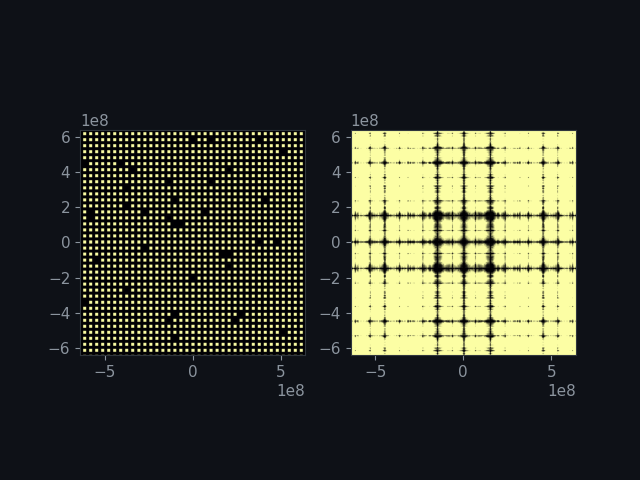

In [ ]:
# %matplotlib widget
ratio_threshold = 0.25
polarity = 0

hole_width_dictionary, mask_dictionary = grid_with_defect(900000, ratio_threshold, polarity)
for i in mask_dictionary.keys():
  mask = np.astype(mask_dictionary[i],int)
  object_mask = mask_generator(hole_width_dictionary[i][0],1,1)
  L_grid = np.shape(mask)[0]
  fig, ax = plt.subplots(1,2)
  im0 = ax[0].imshow(object_mask, cmap='inferno', extent=[-L_grid/2/um, L_grid/2/um, -L_grid/2/um, L_grid/2/um])
  im1 = ax[1].imshow(mask, cmap='inferno', extent=[-L_grid/2/um, L_grid/2/um, -L_grid/2/um, L_grid/2/um])


  # 2. Define your desired physical size in um
  target_width_mm = 15000000 
  target_height_mm = 15000000 

  # 3. Convert mm to inches (1 inch = 25.4 mm)
  width_inches = target_width_mm / 25400
  height_inches = target_height_mm / 25400

  # 4. Get the pixel dimensions from your array
  height_px, width_px = mask.shape
  print("Size - ",width_px, height_px)

  # 5. Calculate the necessary DPI to achieve the target mm size
  dpi_x = width_px / width_inches
  dpi_y = height_px / height_inches

  print("Dpi - ",dpi_x, dpi_y)

  rgba_array0 = np.zeros((L_grid, L_grid, 4), dtype = np.uint8)
  rgba_array0[mask == 0] = [0, 0, 0, 255]
  rgba_array0[mask == 1] = [0, 0, 0, 0]

  rgba_array1 = np.zeros((L_grid, L_grid, 4), dtype = np.uint8)
  rgba_array1[object_mask == 0] = [0, 0, 0, 255]
  rgba_array1[object_mask == 1] = [0, 0, 0, 0]

  # 6. Convert the NumPy array to a Pillow Image
  # Use mode='L' for 8-bit grayscale, or 'F' for 32-bit floating point
  image0 = Image.fromarray(rgba_array0, mode='RGBA')
  image1 = Image.fromarray(rgba_array1, mode='RGBA')

  # 7. Save the image, passing the DPI as metadata
  # PNG and TIFF formats are best for retaining DPI information
  image0.save(f"Object.png", dpi = (dpi_x, dpi_y))
  image1.save(f"Filter.png", dpi=(dpi_x, dpi_y))

  print(f"Saved image. If printed, it will be {target_width_mm}um x {target_height_mm}um.")

### Fingerprint (in progress)

In [ ]:
# %matplotlib inline
# Physical Constants (using Micrometers as base unit for numerical stability)
um = 1e-6
wavelength = 0.7 * um  # 700 nm (Red light)
z_distance = 400000 * um # 40 cm propagation
L_grid = 5000 * um     # 5 mm grid size
N_points = 1280        # 1280x1280 resolution (Fast with FFT) (1280x780)

# Geometry
f_lens = 100000 * um
d1 = z_distance / 4      # Object to Lens1
d2 = z_distance / 4      # Lens1 to focal plane (focal lenght 10 cm)
d3 = z_distance / 4      # Focal plane to Lens2
d4 = z_distance / 4      # Lens2 to Screen

f_lens1 = 1250000 * um
f_lens2 = 100000 * um
d1 = 600000 * um
d2 = 1250000 * um
d3 = 100000 * um
d4 = 100000 * um

# 1. Setup Grid
X, Y, FX, FY = get_grid(N_points, L_grid)

incident_wave = create_aperture(X, Y, type = 'gaussian',params = {'sigma':1
                                                                  })

#____________________________________________________________
#Pure Vessel

My_aperture = create_aperture(X, Y, type = 'image',params = {'path':'/content/Sattvik.tif','threshold': 0.09, 'inverse' : 0})



aperture = create_aperture(X, Y, type = 'image',params = {'path':'/content/Mixed_00001 15_21_37.tif',
                                                               'threshold':0.12, 'inverse':1})

# ==========================================
# 3. Execution Step-by-Step
# ==========================================

# Step 0: Create Source
field_0 = incident_wave * aperture

# Step 1: Propagate to Lens (Diffraction happens here)
field_at_lens1_input = diffraction_angular_spectrum(field_0, wavelength, d1, FX, FY)

# Step 2: Apply Lens
# The wavefront curvature is reversed by the lens
field_at_lens1_output = thin_lens(field_at_lens1_input, X, Y, wavelength, f_lens)

# Step 3: Propagate to the focal plane
field_at_focal_plane = diffraction_angular_spectrum(field_at_lens1_output, wavelength, d2, FX, FY)

#Step 3_0: Inputting an object
field_at_focal_plane_filtered = field_at_focal_plane #* My_aperture

# Step 4: Prpagation from the focal plane to the lens2
field_at_lens2_input = diffraction_angular_spectrum(field_at_focal_plane_filtered, wavelength, d3, FX, FY) #maybe d3 = -d3 check

# Step 5: Apply lens 2 (for making image parallel)
field_at_lens2_output = thin_lens(field_at_lens2_input, X, Y, wavelength, f_lens)

# Step 6: Lens2 to Screen
field_at_screen = diffraction_angular_spectrum(field_at_lens2_output, wavelength, d4, FX, FY)



# ==========================================
# Visualization
# ==========================================

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Input Aperture
ax[0].imshow(np.abs(field_0)**2, cmap='inferno', extent=[-L_grid/2/um, L_grid/2/um, -L_grid/2/um, L_grid/2/um])
ax[0].set_title("Input Aperture Mask")
ax[0].set_xlabel("x (µm)")
ax[0].set_ylabel("y (µm)")

# Plot 2: Focal Plane
im2 = ax[1].imshow(np.log(np.abs(field_at_focal_plane_filtered)**2) + 1e-9, cmap='inferno',
                   extent=[-L_grid/2/um, L_grid/2/um, -L_grid/2/um, L_grid/2/um])
ax[1].set_title(f"Intensity Field at Focal Plane / ASM\n(z = {(d1+d2)/um} µm)")
ax[1].set_xlabel("x (µm)")
plt.colorbar(im2, ax=ax[1], fraction=0.046, pad=0.04)

# Plot 3: Final image
im3 = ax[2].imshow(np.rot90(np.rot90(np.abs(field_at_screen)**2)), cmap='inferno',
                   extent=[-L_grid/2/um, L_grid/2/um, -L_grid/2/um, L_grid/2/um])
ax[2].set_title("Final Image")
ax[2].set_xlabel("x' (µm)")
plt.colorbar(im3, ax=ax[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

### Image/Data Processing

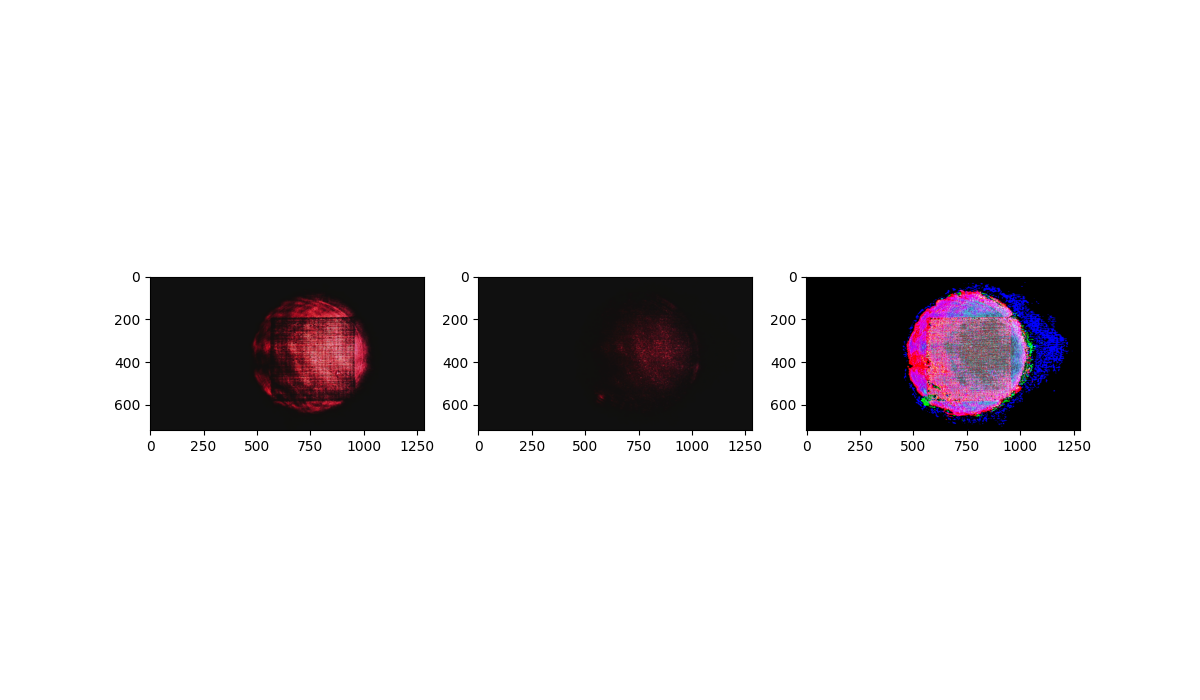

In [ ]:
# %matplotlib widget
original_path = 'd:\\College\\P499 Open Lab Sem 8\\Fourier optics, spatial filtering  and phase contrast microscopy'
folder_name = 'Data'
os.chdir(original_path)
file_list = os.listdir('Data')


for i in file_list:
    if '100_WithoutFilter' in i :
        os.chdir('Data/'+i)
        image_list = os.listdir()
        image_list = [i for i in image_list if 'png' in i]
        reference_image = np.array(Image.open(image_list[0]))

    os.chdir(original_path)

for i in file_list:
    if '100_WithFilter' in  i :
        os.chdir('Data/'+i)
        image_list = os.listdir()
        image_list = [i for i in image_list if 'png' in i]
        distance = 0
        for j in image_list:
            image_temp = np.array(Image.open(j))
            distance_new = np.linalg.norm(image_temp - reference_image)
            if distance_new > distance:
                image = image_temp
                distance = distance_new
            hightlight = image - reference_image
            hightlight = hightlight*(hightlight>=10)
    
    os.chdir(original_path)

fig, ax = plt.subplots(1,3,figsize = (12,7))
ax[0].imshow(reference_image)
ax[1].imshow(image)
ax[2].imshow(hightlight)

In [22]:
"""
Fourier Optics — Batch Spatial Filtering Analysis
==================================================
Each plot is saved as a separate, standalone figure for independent use.

Per pair, the following individual files are saved:
    01_Reference.png
    02_Filtered.png
    03_Ideal.png
    04_Detected_Spots.png
    05_Deviation_Map.png
    06_Change_Map.png
    07_Intensity_Profile.png
    08_Metrics_Bar.png
    09_Intensity_Histogram.png

Output folder structure:
    Analysis_Photo/
        100/   (base set, width 100)
        200/
        ...
        Set2/
            100/
            200/
            ...
    Summary_<metric>.png   (one per key metric, across all widths)

Requirements: numpy, matplotlib, scipy, scikit-image, Pillow
Install     : pip install numpy matplotlib scipy scikit-image Pillow
"""

import os
import re
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from PIL import Image
from scipy import ndimage
from scipy.ndimage import label, gaussian_filter
from skimage.metrics import structural_similarity as ssim
from skimage.filters import threshold_otsu, threshold_local
from skimage.morphology import disk
import warnings
warnings.filterwarnings("ignore")

# ── Global style ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#0e1117", "axes.facecolor":   "#161b22",
    "axes.edgecolor":   "#30363d", "axes.labelcolor":  "#c9d1d9",
    "axes.titlecolor":  "#e6edf3", "xtick.color":      "#8b949e",
    "ytick.color":      "#8b949e", "text.color":       "#c9d1d9",
    "font.family":      "DejaVu Sans", "font.size":    11,
    "grid.color":       "#21262d", "grid.linewidth":   0.5,
    "legend.framealpha": 0.25,     "legend.edgecolor": "#30363d",
    "legend.facecolor": "#161b22",
})
BLUE   = "#3B8BD4"
ORANGE = "#E8593C"
GREEN  = "#1D9E75"
AMBER  = "#EF9F27"
GRAY   = "#8b949e"

FIG_IMG  = (8, 6)    # image figures
FIG_WIDE = (11, 5)   # profile / histogram


# ══════════════════════════════════════════════════════════════════════════════
# FOLDER DISCOVERY
# ══════════════════════════════════════════════════════════════════════════════

def parse_folder_name(name: str):
    m = re.match(
        r"^(\d+)_(With(?:out)?Filter)(?:_(Set2))?(?:_.*)?$",
        name, re.IGNORECASE
    )
    if not m:
        return None
    width   = m.group(1)
    kind    = "without" if "without" in m.group(2).lower() else "with"
    set_tag = m.group(3) if m.group(3) else ""
    return width, kind, set_tag


def discover_pairs(data_dir: str):
    buckets = {}
    for entry in sorted(os.listdir(data_dir)):
        full = os.path.join(data_dir, entry)
        if not os.path.isdir(full):
            continue
        parsed = parse_folder_name(entry)
        if parsed is None:
            print(f"  [skip] unrecognised folder: {entry}")
            continue
        width, kind, set_tag = parsed
        key = (width, set_tag)
        buckets.setdefault(key, {})
        if kind not in buckets[key]:
            buckets[key][kind] = full

    pairs = []
    for (width, set_tag), paths in sorted(buckets.items()):
        if "with" not in paths or "without" not in paths:
            print(f"  [warn] incomplete pair for width={width} set={set_tag!r} — skipping")
            continue
        out_sub = os.path.join("Set2", width) if set_tag else width
        pairs.append({
            "width"      : width,
            "set_tag"    : set_tag,
            "with_dir"   : paths["with"],
            "without_dir": paths["without"],
            "out_sub"    : out_sub,
        })
    return pairs


def load_images_from_pair(without_dir: str, with_dir: str):
    def png_list(d):
        return sorted(f for f in os.listdir(d) if f.lower().endswith(".png"))

    ref_files = png_list(without_dir)
    if not ref_files:
        raise FileNotFoundError(f"No PNG images found in {without_dir}")
    reference_image = np.array(Image.open(os.path.join(without_dir, ref_files[0])))

    filt_files = png_list(with_dir)
    if not filt_files:
        raise FileNotFoundError(f"No PNG images found in {with_dir}")

    best_image, best_dist = None, -1
    for fname in filt_files:
        img = np.array(Image.open(os.path.join(with_dir, fname)))
        if img.shape != reference_image.shape:
            img = np.array(
                Image.fromarray(img).resize(
                    (reference_image.shape[1], reference_image.shape[0]),
                    Image.LANCZOS))
        d = np.linalg.norm(img.astype(float) - reference_image.astype(float))
        if d > best_dist:
            best_dist  = d
            best_image = img

    return reference_image, best_image


# ══════════════════════════════════════════════════════════════════════════════
# IMAGE PROCESSING HELPERS
# ══════════════════════════════════════════════════════════════════════════════

def to_gray_float(img):
    gray = (0.2989 * img[..., 0] + 0.5870 * img[..., 1] + 0.1140 * img[..., 2]
            if img.ndim == 3 else img.astype(np.float32))
    gray = gray.astype(np.float32)
    return gray / gray.max() if gray.max() > 0 else gray


def detect_circular_mask(gray, sigma=8.0):
    blurred = gaussian_filter(gray, sigma=sigma)
    thresh  = threshold_otsu(blurred)
    filled  = ndimage.binary_fill_holes(blurred > thresh * 0.5)
    labeled, n = label(filled)
    if n == 0:
        return np.ones_like(gray, dtype=bool)
    sizes = [np.sum(labeled == k) for k in range(1, n + 1)]
    return ndimage.binary_closing(
        labeled == (np.argmax(sizes) + 1), structure=disk(10))


def normalize_within_mask(img, mask):
    out  = img.copy()
    vals = img[mask]
    out[mask]  = (vals - vals.min()) / np.ptp(vals) if np.ptp(vals) > 0 else vals
    out[~mask] = 0
    return out


def compute_ideal_image(ref_gray, mask, block_size=51, offset=0.02):
    local_thresh  = threshold_local(ref_gray, block_size=block_size, offset=-offset)
    dark_patches  = ndimage.binary_opening(
        ~(ref_gray > local_thresh) & mask, structure=disk(3))
    globally_dark = (ref_gray < threshold_otsu(ref_gray[mask]) * 0.7) & mask
    defect_mask   = (dark_patches | globally_dark) & mask
    return defect_mask.astype(np.float32), defect_mask


def extract_defect_spots(filt_gray, mask, top_frac=0.06):
    thresh = np.percentile(filt_gray[mask], (1 - top_frac) * 100)
    return ndimage.binary_opening(
        (filt_gray > thresh) & mask, structure=disk(2))


def compute_metrics(ref_norm, filt_norm, ideal, defect_mask, detected_spots, mask):
    bg    = mask & ~detected_spots
    sig   = filt_norm[detected_spots].mean()
    noise = filt_norm[bg].std() + 1e-9
    inter = (detected_spots & defect_mask).sum()
    union = (detected_spots | defect_mask).sum()
    fp    = (detected_spots & ~defect_mask & mask).sum()

    def entropy(img, mk):
        h, _ = np.histogram(img[mk], bins=256, range=(0, 1), density=True)
        h = h[h > 0]
        return -np.sum(h * np.log2(h)) / 256

    return {
        "Contrast Ratio"      : (sig / (filt_norm[bg].mean() + 1e-9),
                                 "Spot / background mean  (ideal → ∞)"),
        "SNR (dB)"            : (20 * np.log10(sig / noise),
                                 "20·log(signal/noise std)  (↑ better)"),
        "SSIM vs Ideal"       : (ssim(filt_norm, ideal, data_range=1.0),
                                 "Structural similarity to ideal  (1 = perfect)"),
        "Sparsity (detected)" : (detected_spots[mask].mean(),
                                 "Fraction of aperture that is bright (↓ better)"),
        "Sparsity (ideal)"    : (ideal[mask].mean(),
                                 "Fraction of aperture that are defects"),
        "Jaccard Overlap"     : (inter / (union + 1e-9),
                                 "IoU of spots vs defects  (1 = perfect)"),
        "Defect Recall"       : (inter / (defect_mask.sum() + 1e-9),
                                 "Fraction of true defects captured"),
        "False Positive Rate" : (fp / ((~defect_mask & mask).sum() + 1e-9),
                                 "Spurious bright pixels  (0 = perfect)"),
        "Peak-to-Mean Ratio"  : (filt_norm[mask].max() /
                                 (filt_norm[mask].mean() + 1e-9),
                                 "Sharpness of peaks  (↑ better)"),
        "Filtered Entropy"    : (entropy(filt_norm, mask),
                                 "Shannon entropy (↓ = sparser = closer to ideal)"),
        "Ideal Entropy"       : (entropy(ideal, mask),
                                 "Reference ideal entropy"),
    }


# ══════════════════════════════════════════════════════════════════════════════
# INDIVIDUAL FIGURE BUILDERS
# ══════════════════════════════════════════════════════════════════════════════

def _save(fig, path):
    """Save and immediately close a figure."""
    fig.savefig(path, dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.close(fig)


# ── helpers ──────────────────────────────────────────────────────────────────

def _img_fig(data, cmap, title, label_str):
    """Generic full-frame image figure."""
    fig, ax = plt.subplots(figsize=FIG_IMG)
    im = ax.imshow(data, cmap=cmap, vmin=0, vmax=1)
    ax.set_title(f"{title}\n{label_str}", fontsize=12, pad=8)
    ax.axis("off")
    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, format="%.1f")
    cb.ax.tick_params(labelsize=9)
    fig.tight_layout()
    return fig


def _divmap_fig(diff, cmap, title, label_str):
    """Diverging-colourmap difference image figure."""
    fig, ax = plt.subplots(figsize=FIG_IMG)
    im = ax.imshow(diff, cmap=cmap, norm=Normalize(vmin=-0.5, vmax=0.5))
    ax.set_title(f"{title}\n{label_str}", fontsize=12, pad=8)
    ax.axis("off")
    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, format="%.2f")
    cb.set_label("Intensity difference", fontsize=9)
    cb.ax.tick_params(labelsize=9)
    fig.tight_layout()
    return fig


# ── the 9 figure builders ────────────────────────────────────────────────────

def build_reference(d):
    return _img_fig(d["ref_norm"], "inferno",
                    "Reference Image  (No Filter)", d["label"])


def build_filtered(d):
    return _img_fig(d["filt_norm"], "inferno",
                    "Filtered Image", d["label"])


def build_ideal(d):
    return _img_fig(d["ideal"], "magma",
                    "Ideal Scenario", d["label"])


def build_detected_spots(d):
    return _img_fig(d["detected"].astype(float), "plasma",
                    "Detected Bright Spots", d["label"])


def build_deviation_map(d):
    return _divmap_fig(d["filt_norm"] - d["ideal"], "RdBu_r",
                       "Deviation Map  (Filtered − Ideal)", d["label"])


def build_change_map(d):
    return _divmap_fig(d["filt_norm"] - d["ref_norm"], "RdYlGn",
                       "Change Map  (Filtered − Reference)", d["label"])


def build_intensity_profile(d):
    ref_norm  = d["ref_norm"]
    filt_norm = d["filt_norm"]
    ideal     = d["ideal"]
    mask      = d["mask"]

    cy = int(ndimage.center_of_mass(mask.astype(float))[0])
    x  = np.arange(ref_norm.shape[1])

    fig, ax = plt.subplots(figsize=FIG_WIDE)
    ax.plot(x, ref_norm[cy],  color=BLUE,   lw=1.8, label="Reference")
    ax.plot(x, filt_norm[cy], color=ORANGE, lw=1.8, label="Filtered")
    ax.plot(x, ideal[cy],     color=GREEN,  lw=1.4, ls="--", label="Ideal")
    ax.fill_between(x, filt_norm[cy], ideal[cy],
                    where=(filt_norm[cy] > ideal[cy]),
                    alpha=0.15, color=ORANGE, label="Above ideal")
    ax.fill_between(x, filt_norm[cy], ideal[cy],
                    where=(filt_norm[cy] < ideal[cy]),
                    alpha=0.15, color=BLUE,   label="Below ideal")
    ax.axhline(0, color="#30363d", lw=0.6)
    ax.set_title(f"Horizontal Intensity Profile  (row y = {cy})\n{d['label']}",
                 fontsize=12, pad=8)
    ax.set_xlabel("Pixel  x")
    ax.set_ylabel("Normalised Intensity")
    ax.set_xlim(0, ref_norm.shape[1] - 1)
    ax.set_ylim(-0.05, 1.12)
    ax.legend(fontsize=9, ncol=3, loc="upper left")
    ax.grid(True, ls="--", alpha=0.4)
    fig.tight_layout()
    return fig


def build_metrics_bar(d):
    metrics = d["metrics"]
    names   = list(metrics.keys())
    vals    = [v for v, _ in metrics.values()]
    dvals   = np.clip(vals, -1, 20)
    colors  = [GREEN if v >= 0 else ORANGE for v in vals]

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(names, dvals, color=colors, edgecolor="#30363d", height=0.6)
    for bar, raw in zip(bars, vals):
        ax.text(bar.get_width() + 0.06,
                bar.get_y() + bar.get_height() / 2,
                f"{raw:.4f}", va="center", fontsize=9.5, color="#c9d1d9")
    ax.set_title(f"Quantitative Metrics\n{d['label']}", fontsize=12, pad=8)
    ax.set_xlabel("Value")
    ax.set_xlim(0, max(dvals) * 1.30 + 0.5)
    ax.grid(True, axis="x", ls="--", alpha=0.4)
    fig.tight_layout()
    return fig


def build_histogram(d):
    ref_norm  = d["ref_norm"]
    filt_norm = d["filt_norm"]
    ideal     = d["ideal"]
    mask      = d["mask"]
    bins      = np.linspace(0, 1, 80)

    fig, ax = plt.subplots(figsize=FIG_WIDE)
    ax.hist(ref_norm[mask].ravel(),  bins=bins, color=BLUE,   alpha=0.55,
            label="Reference", density=True)
    ax.hist(filt_norm[mask].ravel(), bins=bins, color=ORANGE, alpha=0.55,
            label="Filtered",  density=True)
    ax.hist(ideal[mask].ravel(),     bins=bins, color=GREEN,  alpha=0.55,
            label="Ideal",     density=True)
    ax.set_title(
        f"Pixel Intensity Distribution  (inside aperture)\n{d['label']}",
        fontsize=12, pad=8)
    ax.set_xlabel("Normalised Intensity")
    ax.set_ylabel("Density")
    ax.legend(fontsize=10)
    ax.grid(True, ls="--", alpha=0.4)
    fig.tight_layout()
    return fig


# ── registry: (filename_stem, builder_function) ──────────────────────────────
FIGURE_REGISTRY = [
    ("01_Reference",           build_reference),
    ("02_Filtered",            build_filtered),
    ("03_Ideal",               build_ideal),
    ("04_Detected_Spots",      build_detected_spots),
    ("05_Deviation_Map",       build_deviation_map),
    ("06_Change_Map",          build_change_map),
    ("07_Intensity_Profile",   build_intensity_profile),
    ("08_Metrics_Bar",         build_metrics_bar),
    ("09_Intensity_Histogram", build_histogram),
]


# ══════════════════════════════════════════════════════════════════════════════
# PER-PAIR RUNNER
# ══════════════════════════════════════════════════════════════════════════════

def run_analysis_and_save(ref_img, filt_img, out_dir, label_str):
    """Run full pipeline; save every figure as an individual PNG."""

    ref_gray  = to_gray_float(ref_img)
    filt_gray = to_gray_float(filt_img)
    mask      = detect_circular_mask(ref_gray + filt_gray * 0.3)
    ref_norm  = normalize_within_mask(ref_gray,  mask)
    filt_norm = normalize_within_mask(filt_gray, mask)
    ideal, defect_mask = compute_ideal_image(ref_norm, mask)
    detected  = extract_defect_spots(filt_norm, mask)
    metrics   = compute_metrics(ref_norm, filt_norm, ideal,
                                defect_mask, detected, mask)

    data = dict(
        ref_norm=ref_norm, filt_norm=filt_norm,
        ideal=ideal, detected=detected,
        mask=mask, metrics=metrics, label=label_str,
    )

    for stem, builder in FIGURE_REGISTRY:
        fig  = builder(data)
        path = os.path.join(out_dir, f"{stem}.png")
        _save(fig, path)
        print(f"      saved  {stem}.png")

    return metrics


# ══════════════════════════════════════════════════════════════════════════════
# SUMMARY PLOTS  (one figure per metric, all widths on same axes)
# ══════════════════════════════════════════════════════════════════════════════

def save_summary_plots(all_results, out_dir):
    key_metrics = ["Contrast Ratio", "SNR (dB)", "SSIM vs Ideal",
                   "Jaccard Overlap", "Defect Recall", "False Positive Rate"]
    colors_map  = {"Base": BLUE, "Set2": ORANGE}
    markers_map = {"Base": "o",  "Set2": "s"}

    groups = {}
    for r in all_results:
        tag = r["set_tag"] if r["set_tag"] else "Base"
        groups.setdefault(tag, []).append(r)
    for tag in groups:
        groups[tag].sort(key=lambda x: int(x["width"]))

    for mkey in key_metrics:
        fig, ax = plt.subplots(figsize=(9, 5))
        for tag, rlist in groups.items():
            widths = [int(r["width"]) for r in rlist]
            vals   = [r["metrics"].get(mkey, (float("nan"),))[0] for r in rlist]
            ax.plot(widths, vals,
                    color=colors_map.get(tag, GREEN),
                    marker=markers_map.get(tag, "^"),
                    lw=2, ms=8, label=tag)
            for w, v in zip(widths, vals):
                ax.annotate(f"{v:.3f}", (w, v),
                            textcoords="offset points", xytext=(5, 5),
                            fontsize=8.5, color=colors_map.get(tag, GREEN))
        ax.set_title(f"Summary — {mkey}  vs  Filter Width", fontsize=12, pad=8)
        ax.set_xlabel("Filter Width")
        ax.set_ylabel(mkey)
        ax.legend(fontsize=10)
        ax.grid(True, ls="--", alpha=0.4)
        fig.tight_layout()

        safe = (mkey.replace(" ", "_")
                    .replace("(", "").replace(")", "")
                    .replace("/", "_").replace("·", ""))
        path = os.path.join(out_dir, f"Summary_{safe}.png")
        _save(fig, path)
        print(f"  → {path}")


# ══════════════════════════════════════════════════════════════════════════════
# MAIN
# ══════════════════════════════════════════════════════════════════════════════

def main():
    # ── CONFIGURE THESE PATHS ─────────────────────────────────────────────
    ROOT_DIR = (
        r"d:\College\P499 Open Lab Sem 8"
        r"\Fourier optics, spatial filtering  and phase contrast microscopy"
    )
    DATA_SUBDIR = "Data"
    OUTPUT_ROOT = os.path.join(ROOT_DIR, "Analysis_Photo")
    # ─────────────────────────────────────────────────────────────────────

    data_dir = os.path.join(ROOT_DIR, DATA_SUBDIR)
    if not os.path.isdir(data_dir):
        sys.exit(f"[ERROR] Data directory not found:\n  {data_dir}")

    os.makedirs(OUTPUT_ROOT, exist_ok=True)

    print(f"\n{'='*65}")
    print(f"  Fourier Optics — Batch Analysis  (individual figures)")
    print(f"  Data  : {data_dir}")
    print(f"  Output: {OUTPUT_ROOT}")
    print(f"{'='*65}\n")

    pairs = discover_pairs(data_dir)
    if not pairs:
        sys.exit("[ERROR] No matching WithFilter / WithoutFilter pairs found.")

    print(f"Found {len(pairs)} pair(s):\n")
    for p in pairs:
        tag = f"[{p['set_tag']}]" if p["set_tag"] else "[Base] "
        print(f"  {tag}  width={p['width']:>5}  "
              f"ref={os.path.basename(p['without_dir'])}  "
              f"flt={os.path.basename(p['with_dir'])}")
    print()

    all_results = []

    for p in pairs:
        label_str = (f"Width = {p['width']}  |  "
                     f"{'Set2' if p['set_tag'] else 'Base Set'}")
        print(f"  ── {label_str} ──")

        out_dir = os.path.join(OUTPUT_ROOT, p["out_sub"])
        os.makedirs(out_dir, exist_ok=True)

        try:
            ref_img, filt_img = load_images_from_pair(
                p["without_dir"], p["with_dir"])
        except FileNotFoundError as e:
            print(f"    [SKIP] {e}\n")
            continue

        try:
            metrics = run_analysis_and_save(ref_img, filt_img,
                                            out_dir, label_str)
        except Exception as e:
            print(f"    [ERROR] {e}\n")
            continue

        all_results.append({
            "width"  : p["width"],
            "set_tag": p["set_tag"],
            "metrics": metrics,
        })

        print(f"    Key metrics:")
        for mname in ["Contrast Ratio", "SNR (dB)", "SSIM vs Ideal",
                      "Jaccard Overlap", "Defect Recall"]:
            val, _ = metrics.get(mname, (float("nan"), ""))
            print(f"      {mname:<25}  {val:.4f}")
        print()

    if len(all_results) >= 2:
        print("  Generating per-metric summary plots …")
        save_summary_plots(all_results, OUTPUT_ROOT)

    print(f"\n{'='*65}")
    print(f"  Done.  All figures saved under: {OUTPUT_ROOT}")
    print(f"{'='*65}\n")


if __name__ == "__main__":
    main()


  Fourier Optics — Batch Analysis  (individual figures)
  Data  : d:\College\P499 Open Lab Sem 8\Fourier optics, spatial filtering  and phase contrast microscopy\Data
  Output: d:\College\P499 Open Lab Sem 8\Fourier optics, spatial filtering  and phase contrast microscopy\Analysis_Photo

  [skip] unrecognised folder: Sanity Moving
  [warn] incomplete pair for width=600 set='' — skipping
Found 8 pair(s):

  [Base]   width=  100  ref=100_WithoutFilter  flt=100_WithFilter
  [Set2]  width=  100  ref=100_WithoutFilter_Set2  flt=100_WithFilter_Set2
  [Base]   width= 1000  ref=1000_WithoutFilter  flt=1000_WithFilter
  [Set2]  width= 1000  ref=1000_WithoutFilter_Set2  flt=1000_WithFilter_Set2
  [Base]   width=  200  ref=200_WithoutFilter  flt=200_WithFilter
  [Set2]  width=  200  ref=200_WithoutFilter_Set2  flt=200_Withfilter_Set2
  [Base]   width=  400  ref=400_WithoutFilter  flt=400_WithFilter
  [Set2]  width=  400  ref=400_WithoutFilter_Set2  flt=400_WithFilter_Set2

  ── Width = 100  |  B